# Will next Monday's run give Anand's analyst the same answer from the same book?

**Week 2, Monday. Chapter 6 of 6.** Chapters 1 to 5 built the Monday suite and made it add up;
this chapter makes it repeat.

**The case.** The cohort are trainee engineers in the data and AI team at Kalpa's Global
Capability Centre, and Kalpa Retail is their internal client. Anand Iyer, its finance
controller, signs a Monday sheet of the revenue tree for every segment, and his analyst reruns
every query behind it before reading a number. Meera Raghavan, Kalpa Retail's CEO, sets budgets
from the sheet. Kavya Nair, the team's senior analyst, reviews each chapter's answer before it
leaves the team. The book is Kalpa Retail's record of every order Finance stands behind; it
lives in the warehouse, Kalpa's Postgres database, which holds the orders for Q1 (April to June
2026) and Q2 (July to September 2026). Booked revenue counts every order at its amount, whatever
its status. Kalpa sells to four segments: Business (corporate buyers), Retail-Core
(everyday shoppers), Retail-Plus (the paid membership tier, whose customers are its members)
and Student.

> "Every Monday I rerun your suite and trace five delivered app orders against the ERP. If my
> rerun differs from yours, I need to know whether the book changed or your query did."
> Anand's analyst, finance, Kalpa Retail

**Who needs the answer.** Anand's analyst reruns the suite every Monday and checks a sample of
orders against the ERP, the system Finance books orders in. A rerun that disagrees with the
team's run on a sample that should be identical, even by a few hundred rupees, makes every
number in the suite suspect, because nobody can say whether the book moved or the query did.

**The questions on the way.**
1. How can a run show that it computed the same thing as last week's?
2. What fingerprint does this Monday's run leave?
3. Which five orders will the analyst trace against the ERP?
4. Does a sort in Python pick the same five?
5. What does the Monday suite tell Anand?

**The metric at stake.** The run itself: the book's fingerprint (row counts, rupees and distinct
customers per table) printed beside the numbers, and the audit sample of five delivered Q2 app
orders. Q2 is July to September 2026.

**What chapters 1 to 5 found.** The book fell 1.6 percent, Rs 10,00,00,000 to Rs 9,84,00,000,
with 244 then 227 customers who bought. Retail-Plus lost 29.4 percent of its revenue, with
customers down 16.5 percent and orders per customer down 22.0 percent. The segments add back to
the book, and the half-year counts each customer once: 301 in the book, 107 in Retail-Plus.

**A real company with the same question.** Netflix's data engineering team described a pattern
it called write, audit, publish: each run's new data is written first to an audit table,
checked against the runs before it on measures such as its row count and its count of missing
values, and published only when the checks set to fail the job pass, while a check set to warn
raises an alert (Michelle Ufford, "Whoops, The Numbers Are Wrong! Scaling Data Quality @
Netflix", DataWorks Summit, San Jose, 13 June 2017).

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D01_06_same_answer_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

Q = blocks("06_same_answer")
print(len(Q), "named queries read from", "C2_W02_D01_06_same_answer_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

7 named queries read from C2_W02_D01_06_same_answer_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


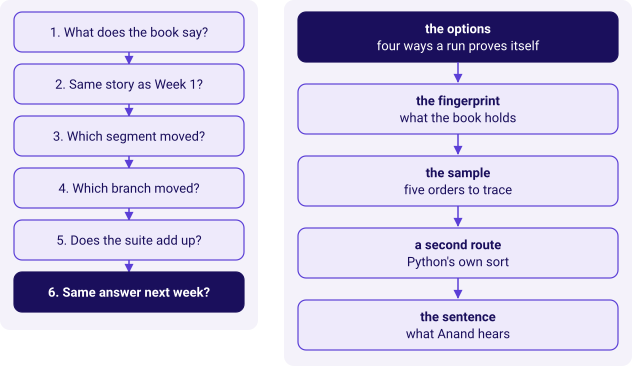

In [2]:
kit.side_by_side(
    kit.ladder(['What does the book say?', 'Same story as Week 1?', 'Which segment moved?', 'Which branch moved?', 'Does the suite add up?', 'Same answer next week?'], lit=5, show=False),
    kit.vflow(['the options\nfour ways a run proves itself', 'the fingerprint\nwhat the book holds', 'the sample\nfive orders to trace', "a second route\nPython's own sort", 'the sentence\nwhat Anand hears'], lit=0, show=False),
)

## 1. The options: how can a run show that it computed the same thing as last week's?

Next Monday the analyst reruns the suite. Four ways a team could make a difference between the
two runs explain itself:

| Option | Stored with each run | Access it needs | What it can tell apart |
|---|---|---|---|
| A. Rerun and compare by eye | Nothing | Read | Whatever someone happens to notice |
| B. A fingerprint block that runs with the suite: rows, rupees and distinct customers per table, printed beside the numbers | A handful of numbers, kept with the run's output | Read | A changed book from a changed query |
| C. Snapshot each Monday's outputs into a table | Every output row | Write, to a schema the team owns | What changed in any output, row by row |
| D. Write, audit, publish: compute into a hidden table, check it, then release it | A staging table per run | Write, and a scheduler | A bad run, stopped before anyone reads it |

**Predict before you run.** Option B's fingerprint for the two tables the suite reads: how many
numbers does it store?

- a) 2, one row count per table.
- b) Seven: four for orders and three for customers, which has no rupees.
- c) About 20, one per output row.
- d) 1,340, one per row read.

-- The book's fingerprint: what each table holds, and the totals the suite's numbers must add to.
SELECT 'orders'    AS table_name, count(*) AS rows, sum(amount) AS rupees,
       count(DISTINCT customer_id) AS distinct_customers, max(order_date) AS latest_date
FROM   orders
UNION ALL
SELECT 'customers', count(*), NULL, count(DISTINCT customer_id), max(joined_date)
FROM   customers;


table_name,rows,rupees,distinct_customers,latest_date
orders,1000,"Rs 19,84,00,000",301,2026-09-28
customers,340,NULL,340,2025-12-25


option,numbers stored per run,access
A. by eye,0,read
B. fingerprint,7,read
C. snapshot,18 rows a Monday,write
"D. write, audit, publish",a staging table,write and a scheduler


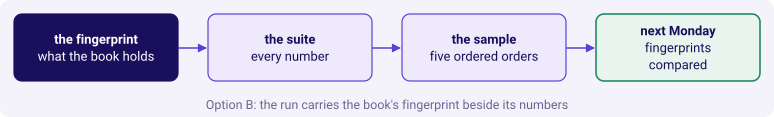

In [3]:
fp = run("c6_fingerprint", "The book's fingerprint", money=("rupees",))
numbers = sum(1 for r in fp for k, v in r.items() if k != "table_name" and v is not None)
suite = {}
for stem in ("01_book", "03_which_segment", "04_which_branch", "05_does_it_add_up"):
    suite.update(blocks(stem))
parts = [(label, len(kit.sql(suite[name]))) for label, name in
         (("the book", "c1_book"), ("segment-quarters", "c3_segments"),
          ("branches", "c4_branches"), ("half-years", "c5_half_year"))]
outputs = sum(n for _, n in parts)
kit.table(["option", "numbers stored per run", "access"],
          [("A. by eye", 0, "read"), ("B. fingerprint", numbers, "read"),
           ("C. snapshot", f"{outputs} rows a Monday", "write"), ("D. write, audit, publish", "a staging table", "write and a scheduler")],
          caption="Sized on this suite: its outputs are " + ", ".join(f"{n} {label}" for label, n in parts)
                  + f", {outputs} rows a Monday")
kit.flow(["the fingerprint\nwhat the book holds", "the suite\nevery number", "the sample\nfive ordered orders",
          "next Monday\nfingerprints compared"], kinds=["lit", None, None, "good"],
         title="Option B: the run carries the book's fingerprint beside its numbers")

**What happened.** The answer is b: seven numbers, four for `orders` and three for `customers`,
whose rupee column is empty. They are cheap to keep and they answer the analyst's first
question: if next Monday's fingerprint matches this one, the book has not changed, so any
difference in the numbers is the query's.

**The best-fit call.** Option B, a fingerprint block at the top of the suite, together with an
`ORDER BY` on a unique column in every list. The team has read access, which rules out C and D,
and B tells a changed book from a changed query, which is the analyst's question. **What would
change the call:** once the platform lead grants a schema the team can write to, option D runs
the audit before the numbers are released, which is better than finding the problem after
Anand has read them.

In [4]:
orders_fp = next(r for r in fp if r["table_name"] == "orders")
kit.check("the fingerprint stores seven numbers", numbers == 7)
kit.check("the orders fingerprint matches the book the suite reports",
          (orders_fp["rows"], num(orders_fp["rupees"]), orders_fp["distinct_customers"]) == (1000, 198400000, 301))

## 2. What fingerprint does this Monday's run leave?

The fingerprint reads each table once: its rows, its rupees, its distinct customers and its
latest date. Printed at the top of each Monday's run, it is the first thing the analyst compares.

**Predict before you run.** Overnight the warehouse reloads, and two order rows are rewritten
with the values they already hold. Does the fingerprint change?

- a) Yes: two rows were written, so the row count moves.
- b) Yes: the rupees move, since the rows were rewritten.
- c) No: the rows, the rupees and the customers are all the same.
- d) It cannot be read during a reload.

table,this Monday,after the reload
orders,"1,000 rows, Rs 19,84,00,000, 301 customers","1,000 rows, Rs 19,84,00,000, 301 customers"
customers,"340 rows, no rupees, 340 customers","340 rows, no rupees, 340 customers"


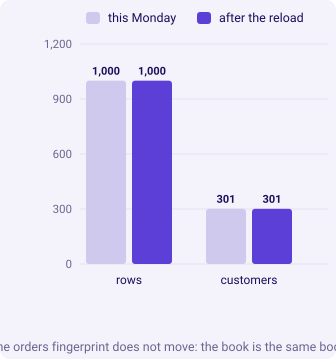

In [5]:
conn = kit.connect()
try:
    steps = statements(Q["c6_sample_after_reload"])
    update = next(s for s in steps if s.upper().startswith("UPDATE"))
    kit.sql(update, conn=conn)
    fp_after = kit.sql(Q["c6_fingerprint"], conn=conn)
finally:
    conn.rollback()
    conn.close()
before = {r["table_name"]: (r["rows"], num(r["rupees"]), r["distinct_customers"]) for r in fp}
after = {r["table_name"]: (r["rows"], num(r["rupees"]), r["distinct_customers"]) for r in fp_after}
kit.table(["table", "this Monday", "after the reload"],
          [(t, f"{before[t][0]:,} rows, {kit.rupees(before[t][1]) if before[t][1] else 'no rupees'}, {before[t][2]} customers",
            f"{after[t][0]:,} rows, {kit.rupees(after[t][1]) if after[t][1] else 'no rupees'}, {after[t][2]} customers")
           for t in before], caption="The fingerprint before and after the reload")
kit.columns(["rows", "customers"], [("this Monday", [before["orders"][0], before["orders"][2]]),
                                    ("after the reload", [after["orders"][0], after["orders"][2]])],
            title="The orders fingerprint does not move: the book is the same book")

In [6]:
kit.check("the reload leaves the fingerprint unchanged", before == after)
kit.check("the warehouse is back as it was after the rollback",
          kit.sql("SELECT count(*) AS n, sum(amount) AS s FROM orders")[0]["n"] == 1000)

**What happened.** The answer is c. The reload rewrote two rows with their own values, so the
book holds the same 1,000 orders, the same Rs 19,84,00,000 and the same 301 customers. Whatever
differs between the two runs after this reload cannot be the book.

## 3. Which five orders will the analyst trace against the ERP?

The analyst traces five delivered Q2 app orders. The quickest query asks for five:

```sql
SELECT order_id, amount FROM orders
WHERE quarter = 'Q2' AND channel = 'app' AND status = 'delivered'
LIMIT 5;
```

**Predict before you run.** With no `ORDER BY`, which five rows come back?

- a) The five with the smallest order ids.
- b) The five most recent orders.
- c) Whichever five the database reaches first, which can change between runs.
- d) Five chosen at random on every run.

-- The question: five delivered Q2 app orders for the analyst to trace. (The quickest way to write it.)
SELECT order_id, amount
FROM   orders
WHERE  quarter = 'Q2' AND channel = 'app' AND status = 'delivered'
LIMIT  5;


order_id,amount
KR-00542,Rs 790
KR-00544,Rs 960
KR-00545,Rs 680
KR-00546,Rs 500
KR-00547,Rs 970


order_id,amount
KR-00545,Rs 680
KR-00546,Rs 500
KR-00547,Rs 970
KR-00549,Rs 970
KR-00553,"Rs 1,470"


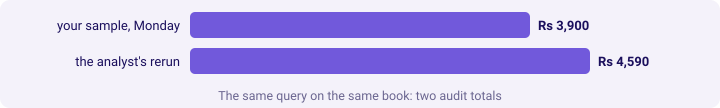

In [7]:
first = run("c6_sample_hurried", "Your five, on Monday", money=("amount",))
conn = kit.connect()
try:
    kit.sql(update, conn=conn)
    select = next(s for s in statements(Q["c6_sample_after_reload"]) if s.upper().startswith("SELECT"))
    second = kit.sql(select, conn=conn)
finally:
    conn.rollback()
    conn.close()
show(second, "The analyst's five, the same query after the overnight reload", money=("amount",))
t1, t2 = sum(num(r["amount"]) for r in first), sum(num(r["amount"]) for r in second)
kit.bars([("your sample, Monday", t1), ("the analyst's rerun", t2)], fmt=kit.rupees,
         title="The same query on the same book: two audit totals")

**The plausible wrong answer.** Your five orders total Rs 3,900 and the analyst's rerun totals
Rs 4,590. The audit reports a Rs 690 disagreement on a sample that should have been identical,
and with it every other number in the suite comes under question.

**Why it is wrong.** A table has no order. Without `ORDER BY` the rows come back "in an
unspecified order", which "will depend on the scan and join plan types and the order on disk,
but it must not be relied on" (PostgreSQL 16 documentation, sorting rows), so `LIMIT` returns
"an unpredictable subset of the query's rows" (the same documentation, `LIMIT` and `OFFSET`).
Postgres writes a rewritten row as a new version in a new place, so after the reload the first
five rows the database reaches are a different five. The answer is c.

**The check that exposes it.** The fingerprint said the book did not change; the samples say the
five did.

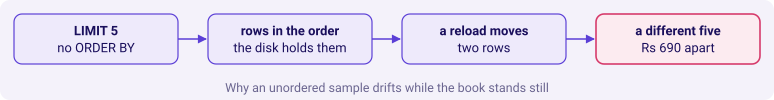

In [8]:
ids1, ids2 = [r["order_id"] for r in first], [r["order_id"] for r in second]
kit.flow(["LIMIT 5\nno ORDER BY", "rows in the order\nthe disk holds them", "a reload moves\ntwo rows",
          "a different five\nRs 690 apart"], kinds=[None, None, None, "bad"],
         title="Why an unordered sample drifts while the book stands still")
kit.check("the book did not change", before == after)
kit.check("the unordered sample changed", ids1 != ids2, f"{len(set(ids1) - set(ids2))} of 5 orders differ")

**The fix, and what it changed.** Order by a column no two rows share, then limit. `order_id` is
the table's key, so `ORDER BY order_id LIMIT 5` names the same five orders on every run.

In [9]:
fixed = run("c6_sample", "The fix, on Monday", money=("amount",))
conn = kit.connect()
try:
    steps = statements(Q["c6_sample_after_reload_fixed"])
    kit.sql(next(s for s in steps if s.upper().startswith("UPDATE")), conn=conn)
    fixed_after = kit.sql(next(s for s in steps if s.upper().startswith("SELECT")), conn=conn)
finally:
    conn.rollback()
    conn.close()
show(fixed_after, "The fix, after the same reload", money=("amount",))
kit.check("the ordered sample is the same five after the reload",
          [r["order_id"] for r in fixed] == [r["order_id"] for r in fixed_after])
kit.check("the ordered sample totals Rs 3,900", sum(num(r["amount"]) for r in fixed) == 3900)

-- The fix: order by a column no two rows share, then limit, so every run draws the same five.
SELECT order_id, amount
FROM   orders
WHERE  quarter = 'Q2' AND channel = 'app' AND status = 'delivered'
ORDER  BY order_id
LIMIT  5;


order_id,amount
KR-00542,Rs 790
KR-00544,Rs 960
KR-00545,Rs 680
KR-00546,Rs 500
KR-00547,Rs 970


order_id,amount
KR-00542,Rs 790
KR-00544,Rs 960
KR-00545,Rs 680
KR-00546,Rs 500
KR-00547,Rs 970


**What happened.** Ordered by `order_id`, the five are KR-00542, KR-00544, KR-00545, KR-00546
and KR-00547 before and after the reload, Rs 3,900 both times. The analyst now traces the orders
you traced.

## 4. A second route: are they the first five by order id, counted without a sort?

The first route asked the database to sort and cut. The second route never sorts and never cuts:
it counts the delivered Q2 app orders whose id sits at or below the last id on a sample. If the
sample is the first five by order id, exactly five candidates sit there and their rupees are the
sample's own; if the sample skipped an order, the count runs above five. A rerun of the ordered
query could only repeat it, and this count can disagree with it.

**Predict before you run.** The analyst's unordered rerun drew KR-00545, KR-00546, KR-00547,
KR-00549 and KR-00553. How many candidates sit at or below KR-00553?

- a) 5, the five the rerun drew.
- b) 6.
- c) 7.
- d) 94, every candidate.

-- The second route, with no sort and no LIMIT: count the candidates whose id sits at or below the
-- last id on the analyst's list, KR-00547. If the list is the first five by order id, the count is 5
-- and the rupees are the list's own; a list that skipped an order makes the count run above 5.
SELECT count(*) AS candidates_up_to_it, sum(amount) AS rupees
FROM   orders
WHERE  quarter = 'Q2' AND channel = 'app' AND status = 'delivered'
  AND  order_id <= 'KR-00547';


sample,its last id,candidates at or below it,their rupees
the ordered five,KR-00547,5,"Rs 3,900"
the unordered rerun,KR-00553,7,"Rs 6,340"


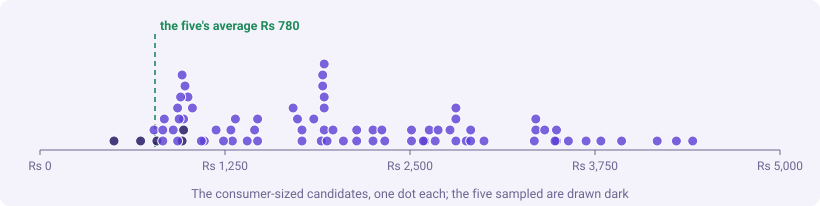

94 candidates, 80 of them under Rs 5,000


In [10]:
route = Q["c6_up_to_last"]
print(route)
last_fixed = fixed[-1]["order_id"]
last_rerun = max(r["order_id"] for r in second)
on_fixed = kit.sql(route)[0]
on_rerun = kit.sql(route.replace(f"'{last_fixed}'", f"'{last_rerun}'"))[0]
kit.table(["sample", "its last id", "candidates at or below it", "their rupees"],
          [("the ordered five", last_fixed, on_fixed["candidates_up_to_it"], kit.rupees(num(on_fixed["rupees"]))),
           ("the unordered rerun", last_rerun, on_rerun["candidates_up_to_it"], kit.rupees(num(on_rerun["rupees"])))],
          caption="The second route: a count with no sort, set against each sample")
candidates = kit.sql(Q["c6_candidates"])
small = [num(r["amount"]) for r in candidates if num(r["amount"]) < 5000]
kit.strip(small, markers=[("the five's average", 780, "good")], fmt=kit.rupees, lo=0, hi=5000,
          lit=tuple(i for i, r in enumerate(r for r in candidates if num(r["amount"]) < 5000)
                    if r["order_id"] in {f["order_id"] for f in fixed}),
          title="The consumer-sized candidates, one dot each; the five sampled are drawn dark")
print(f"{len(candidates)} candidates, {len(small)} of them under Rs 5,000")

In [11]:
kit.check("exactly five candidates sit at or below the ordered sample's last id, worth its Rs 3,900",
          on_fixed["candidates_up_to_it"] == 5
          and num(on_fixed["rupees"]) == sum(num(r["amount"]) for r in fixed) == 3900)
kit.check("the count catches the unordered rerun: more than five sit at or below its last id",
          on_rerun["candidates_up_to_it"] > 5, f"{on_rerun['candidates_up_to_it']} candidates")

**What happened.** The answer is c: seven. The rerun's five stop at KR-00553, and seven
candidates sit at or below it, so the rerun skipped KR-00542 and KR-00544 and is not the first
five. The ordered five stop at KR-00547 with exactly five candidates at or below it, worth
Rs 3,900, the sample's own total, so the count agrees with the ordered query and disagrees with
the unordered one. The dots are the 80 candidates under Rs 5,000, with the sampled five drawn
dark and the marker at their average, Rs 780; the other 14 are large Business orders, off this
scale.

## 5. What does the Monday suite tell Anand?

The day's answer is one message, with its evidence and its caveat, that Anand can forward
without rewriting.

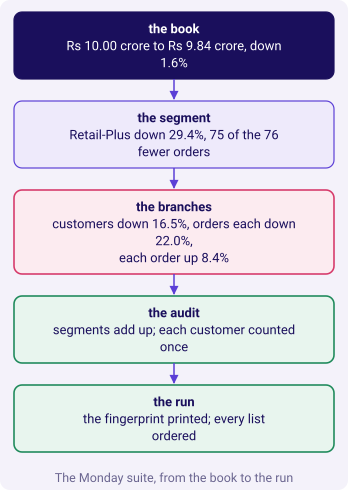

what Anand asked,what the suite now does
computed from the warehouse itself,every number is a named query on the book
every segment,"one grouped query, ratios in numeric, thin groups flagged"
nothing a person can mistype,"no export, no copied value; the run checks its own sums"
an analyst who audits every line,"a comment on every step, and a fingerprint beside every run"


In [12]:
kit.vflow(["the book\nRs 10.00 crore to Rs 9.84 crore, down 1.6%",
           "the segment\nRetail-Plus down 29.4%, 75 of the 76 fewer orders",
           "the branches\ncustomers down 16.5%, orders each down 22.0%,\neach order up 8.4%",
           "the audit\nsegments add up; each customer counted once",
           "the run\nthe fingerprint printed; every list ordered"],
          kinds=["lit", None, "bad", "good", "good"],
          title="The Monday suite, from the book to the run")
kit.table(["what Anand asked", "what the suite now does"],
          [("computed from the warehouse itself", "every number is a named query on the book"),
           ("every segment", "one grouped query, ratios in numeric, thin groups flagged"),
           ("nothing a person can mistype", "no export, no copied value; the run checks its own sums"),
           ("an analyst who audits every line", "a comment on every step, and a fingerprint beside every run")],
          caption="The ask, answered line by line")

**The sentence to Anand.** "Anand, the Monday suite now runs on the warehouse itself. Booked
revenue fell 1.6 percent, from Rs 10.00 crore to Rs 9.84 crore, and Retail-Plus carries the fall
in orders: its revenue is down 29.4 percent because 16.5 percent fewer members bought and each
ordered 22.0 percent less often, while each order was worth 8.4 percent more. The counts are
named for what they count and printed beside
every ratio, and each run prints the book's fingerprint, so a rerun on the same book gives the
same answer.
One caveat: last week's extract showed customers flat, and the full book shows 7.0 percent fewer
customers in Q2."

> **Kavya's review.** Order every audit sample on a column no two rows share, and print the book's
> fingerprint beside the numbers, so a difference next Monday says whether the book moved or
> the query did.

### In the interview: what does LIMIT without ORDER BY return, and what do you suspect when a number moves overnight?

**[F] What does LIMIT without ORDER BY return?** Whichever rows the database reaches first, which
depends on the plan and on where rows sit on disk, so it can change between runs with no change
to the data. Postgres documents it as an unpredictable subset. Order by a column, or a set of
columns, that no two rows share, and then limit.

**[F] Your KPI moved 30 percent overnight and the data did not change; what do you suspect?**
The run, then the query. Check the book's fingerprint first. If the rows and rupees are the
same, check the run's parameters (the date window, the time zone) and anything it depends on
that changed overnight (a view, a deploy, a cached result). Then look for today's suspects: a
definition that changed between runs, a denominator that shifted (a count of rows where people
were meant, an average that skips missing values), integer division, and, when the number is
computed on a sample, an unordered `LIMIT`.

### Depth: what does Netflix's audit check, and what would Kalpa's add?

In the Netflix talk the audit step sets each new batch beside the runs before it. One slide
puts a new batch of 17,240 rows with 17,240 missing values beside the previous day's 16,135
rows with 21: every value of the column was missing. In the talk's rules the row-count checks
fail the job, while the missing-value check only warns, and its walk-through flags that batch
with a warning. A fingerprint that stores the count of missing amounts and customer ids beside
the rows and rupees would put the same failure in front of the team at Kalpa before Anand read
a number built on it. Kalpa's warehouse holds no missing value in any column today, which is
exactly what the fingerprint would prove each Monday.

## So will next Monday's run give the analyst the same answer?

1. **How can a run show it computed the same thing?** A fingerprint block that runs with the
   suite and prints seven numbers about the book, with an `ORDER BY` on a unique column in every
   list; write, audit, publish once the team can write to a schema.
2. **What fingerprint does this run leave?** 1,000 orders, Rs 19,84,00,000 and 301 customers in
   `orders`, and 340 rows in `customers`; the overnight reload left it unchanged.
3. **Which five orders will the analyst trace?** KR-00542, KR-00544, KR-00545, KR-00546 and
   KR-00547, Rs 3,900, once the query orders by `order_id`; without it the rerun drew a
   different five worth Rs 4,590.
4. **Does a count with no sort confirm the five?** Yes: exactly five of the 94 candidates sit at
   or below KR-00547, worth Rs 3,900, while seven sit at or below the unordered rerun's last
   id, so the count catches the sample that drifted.
5. **What does the suite tell Anand?** The book fell 1.6 percent; Retail-Plus carries the fall
   in orders, down 29.4 percent on fewer members buying and each buying less often, while each
   order grew 8.4 percent larger; and every number now reruns the same on the same book.

Tomorrow Anand asks the next question: how much of what was booked was actually collected.

In [13]:
kit.check_summary()